# Task 1: Data Preparation


In [1]:
# Start from here to write your code for Task 1. Please also feel free to add more cells in this ipynb file. 
#Loads the correct extentions needed  to run code for Task 1.
import pandas as pd
import numpy as np
import re

In [2]:
#1 Load csv into a data frame
df = pd.read_csv("victorian_road_crash_data.csv")

In [3]:
#Fixes the date and time columns to be in the correct format for easier analysis.
df['ACCIDENT_DATE'] = pd.to_datetime(df['ACCIDENT_DATE'], format='%d/%m/%Y', errors='coerce')
df['ACCIDENT_TIME'] = pd.to_datetime(df['ACCIDENT_TIME'], format='%H:%M:%S', errors='coerce').dt.time

In [4]:
#Fixing some of the missing data
# Will drop the SRNS column as it is missing a good portion of data
df = df.drop(columns=['SRNS']) 

#dropping rows with missing values in the specified columns as it is a small portion of data and not really needed if we have suburb
df = df.dropna(subset=['LATITUDE', 'LONGITUDE', 'NO_OF_VEHICLES', ])

#will fill the missing values with a unknown for caterogical data 
categorical_cols = ['ROAD_NAME', 'ROAD_TYPE', 'LGA_NAME', 'DTP_REGION', 
                    'DEG_URBAN_NAME', 'RMA', 'DIVIDED', 'STAT_DIV_NAME']
df[categorical_cols] = df[categorical_cols].fillna('Unknown')

In [5]:
#drops the non needed vicgrid due to having lat x long
df = df.drop(columns=['VICGRID_X', 'VICGRID_Y'], errors='ignore')

# we need to keep the lat and long so itll filted out junk ones
df = df.dropna(subset=['LATITUDE', 'LONGITUDE'])

In [ ]:
# fix messy day of week values (weekend is ambiguous, so we'll just call it Saturday)
day_fix = {'Thu': 'Thursday', 'Weekend': 'Saturday'}
df['DAY_OF_WEEK'] = df['DAY_OF_WEEK'].replace(day_fix)
# clean up the bad light condition entries
light_fix = {'Unk.': 'Unknown', 'No': 'Unknown', 'Days': 'Day'}
df['LIGHT_CONDITION'] = df['LIGHT_CONDITION'].replace(light_fix)

In [6]:
# Cleans the SPEED_ZONE column and identifies if speed is unknown or other, replacing with NaN
def clean_speed(val):
    if pd.isna(val):
        return np.nan
    val = str(val).lower()

    if 'not know' in val or 'other' in val:
        return np.nan

    # Use regex to extract the number and return it as a cleaned integer
    nums = re.findall(r'\d+', val)
    if nums:
        speed = int(nums[0])
        # Filter out anomalies like 10000 km/hr
        if speed > 110 or speed == 0:
            return np.nan
        return speed
    return np.nan  # Fallback for any unhandled strings

In [7]:
# Convert vehicle count columns to integers (no decimals needed)
cols_to_fix = [
    'NO_OF_VEHICLES', 'HEAVYVEHICLE', 'PASSENGERVEHICLE',
    'MOTORCYCLE', 'PT_VEHICLE'
]
for col in cols_to_fix:
    df[col] = df[col].astype(int)

df['ROAD_ROUTE_1'] = df['ROAD_ROUTE_1'].fillna(0).astype(int)

In [ ]:

# apply the speed cleaning function and store as a nullable integer
df['SPEED_ZONE_NUM'] = df['SPEED_ZONE'].apply(clean_speed).astype('Int64')

# Int64 allows for ibts + NANS
cols_to_fix = ['SPEED_ZONE_NUM']
for col in cols_to_fix:
    df[col] = df[col].astype('Int64')

In [10]:
# 5. diplays that it processed correctely and then displays the first few rows to show the changes
print(f"Data successfully cleaned. New shape: {df.shape}")
display(df.head())

Data successfully cleaned. New shape: (150395, 50)


,ACCIDENT_NO,ACCIDENT_DATE,ACCIDENT_TIME,ACCIDENT_TYPE,DAY_OF_WEEK,DCA_CODE,DCA_CODE_DESCRIPTION,LIGHT_CONDITION,POLICE_ATTEND,ROAD_GEOMETRY,...,NO_OF_VEHICLES,HEAVYVEHICLE,PASSENGERVEHICLE,MOTORCYCLE,PT_VEHICLE,DEG_URBAN_NAME,RMA,DIVIDED,STAT_DIV_NAME,SPEED_ZONE_NUM
0,T20150000784,2015-01-01,17:50:00,Collision with vehicle,Thursday,163,VEHICLE STRIKES DOOR OF PARKED/STATIONARY VEHICLE,Day,No,Not at intersection,...,2,0,1,0,0,MELB URBAN,Arterial Highway,Undivided,Metro,50
1,T20150000043,2015-01-01,19:30:00,No collision and no object struck,Thursday,184,OUT OF CONTROL ON CARRIAGEWAY (ON BEND),Dusk/Dawn,Yes,T intersection,...,1,0,0,1,0,RURAL VICTORIA,Arterial Other,Undivided,Metro,60
2,T20150000037,2015-01-01,19:00:00,Collision with vehicle,Thursday,110,CROSS TRAFFIC(INTERSECTIONS ONLY),Dusk/Dawn,Yes,Cross intersection,...,2,0,1,0,0,MELB URBAN,Arterial Other,Divided,Metro,60
3,T20150000008,2015-01-01,00:10:00,Collision with vehicle,Thursday,120,HEAD ON (NOT OVERTAKING),Dark No street lights,Yes,Not at intersection,...,2,0,0,2,0,RURAL VICTORIA,Unknown,Unknown,Country,100
4,T20150000050,2015-01-01,04:00:00,Struck Pedestrian,Thursday,109,ANY MANOEUVRE INVOLVING PED NOT INCLUDED IN DC...,Dark No street lights,Yes,Not at intersection,...,1,0,1,0,0,RURAL VICTORIA,Local Road,Undivided,Country,50


In [11]:
df.to_csv('cleaned.csv', index=False)

# Task 2: Data Exploration

## Task 2.1 

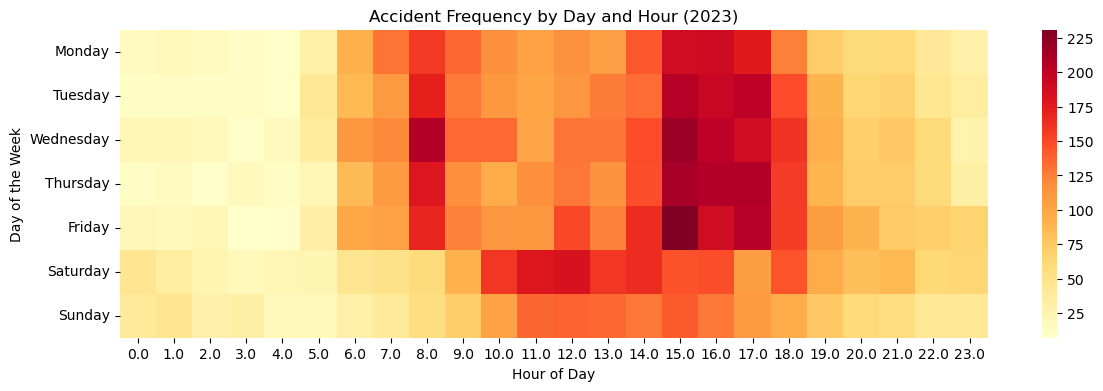

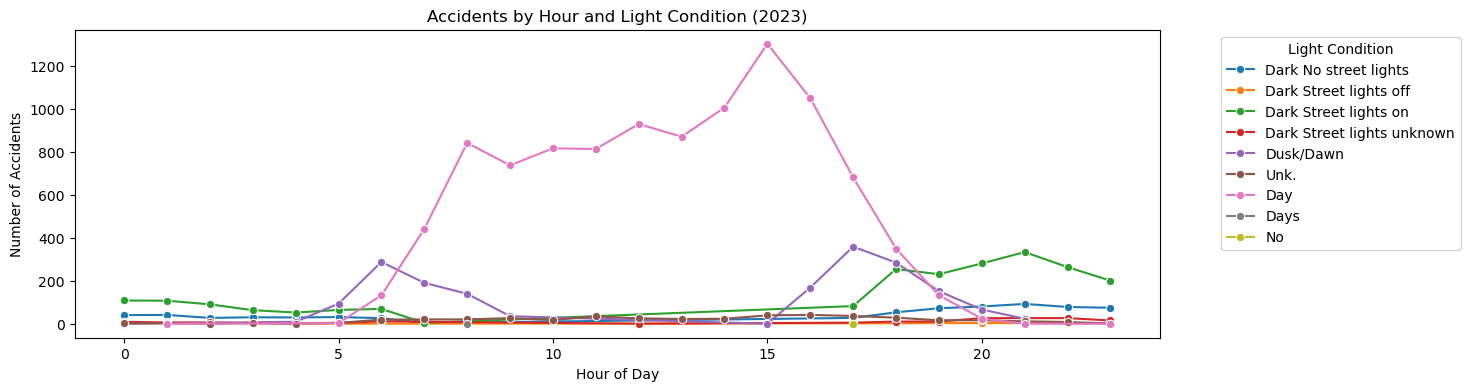

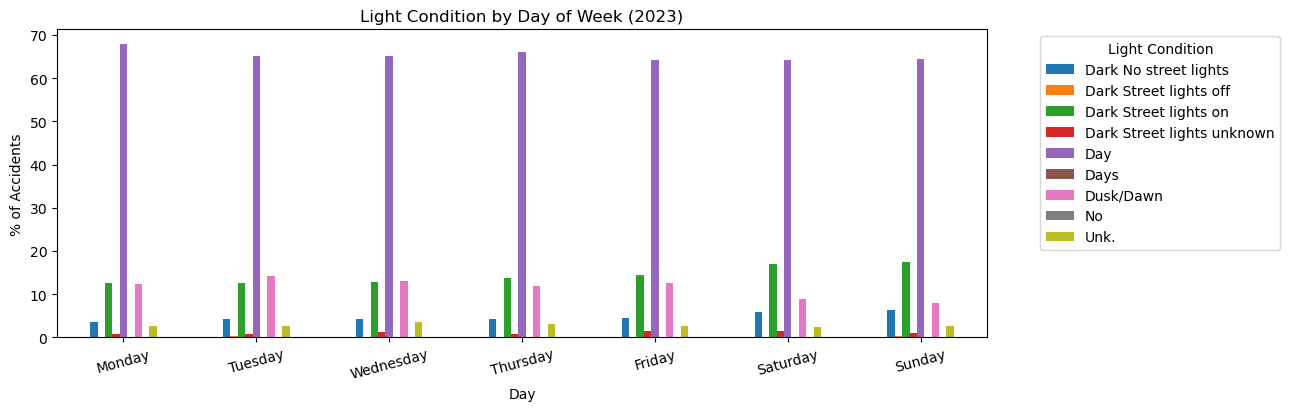

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# filter for 2023 only
df_2023 = df[df['ACCIDENT_DATE'].dt.year == 2023].copy()

# get the hour from the time column
df_2023['HOUR'] = df_2023['ACCIDENT_TIME'].apply(lambda t: t.hour)

# put days in the right order
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# chart 1 - heatmap of accidents by day and hour
heatmap_data = df_2023.groupby(['DAY_OF_WEEK', 'HOUR']).size().unstack(fill_value=0).reindex(day_order)

plt.figure(figsize=(14, 4))
sns.heatmap(heatmap_data, cmap='YlOrRd')
plt.title('Accident Frequency by Day and Hour (2023)')
plt.xlabel('Hour of Day')
plt.ylabel('Day of the Week')
plt.show()

# chart 2 - how light condition changes across hours
light_hour = df_2023.groupby(['HOUR', 'LIGHT_CONDITION']).size().reset_index(name='COUNT')

plt.figure(figsize=(14, 4))
sns.lineplot(data=light_hour, x='HOUR', y='COUNT', hue='LIGHT_CONDITION', marker='o')
plt.title('Accidents by Hour and Light Condition (2023)')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Accidents')
plt.legend(title='Light Condition', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# chart 3 - light condition breakdown by day
light_day = df_2023.groupby(['DAY_OF_WEEK', 'LIGHT_CONDITION']).size().unstack(fill_value=0).reindex(day_order)
light_day_pct = light_day.div(light_day.sum(axis=1), axis=0) * 100

light_day_pct.plot(kind='bar', figsize=(12, 4))
plt.title('Light Condition by Day of Week (2023)')
plt.xlabel('Day')
plt.ylabel('% of Accidents')
plt.xticks(rotation=15)
plt.legend(title='Light Condition', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## Task 2.2 

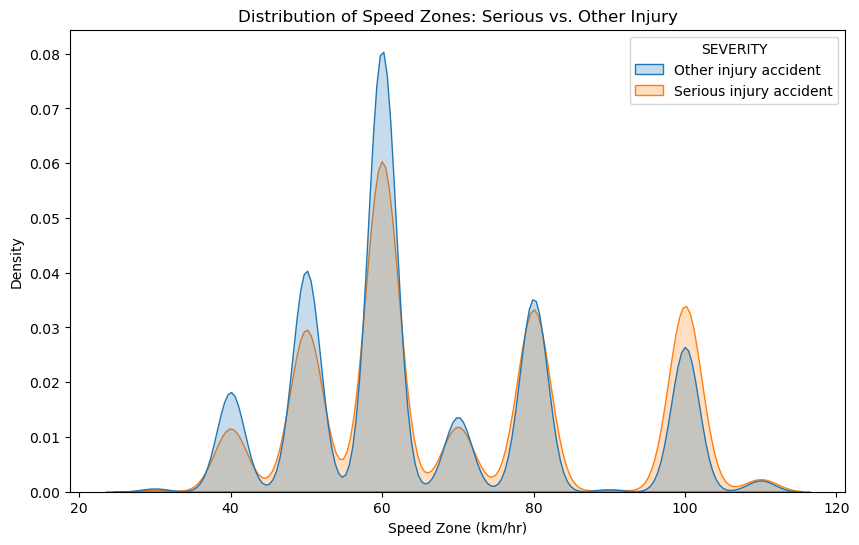

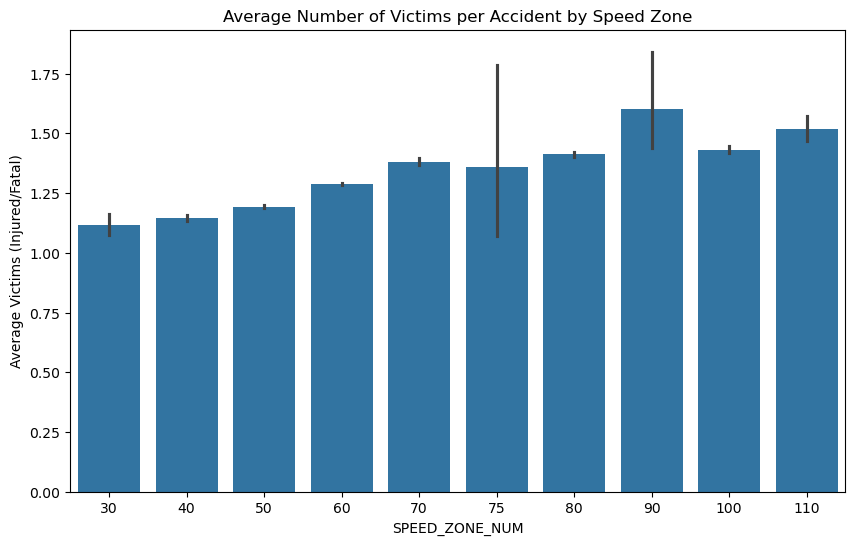

In [ ]:
# 1. Filter for the two specific categories requested
severity_df = df[df['SEVERITY'].isin(['Serious injury accident', 'Other injury accident'])]

# 2. Distribution Plot
plt.figure(figsize=(10, 6))
sns.kdeplot(data=severity_df, x='SPEED_ZONE_NUM', hue='SEVERITY', fill=True, common_norm=False)
plt.title('Distribution of Speed Zones: Serious vs. Other Injury')
plt.xlabel('Speed Zone (km/hr)')
plt.ylabel('Density')
plt.show()

# 3. Relationship: Speed vs Total Victims (INJ_OR_FATAL)
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='SPEED_ZONE_NUM', y='INJ_OR_FATAL', estimator=np.mean)
plt.title('Average Number of Victims per Accident by Speed Zone')
plt.ylabel('Average Victims (Injured/Fatal)')
plt.show()

## Task 2.3 

C:\Users\tommy\AppData\Local\Temp\ipykernel_11420\4243286382.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top5, x='LGA_NAME', y='SPEED_ZONE_NUM', palette="Set2")


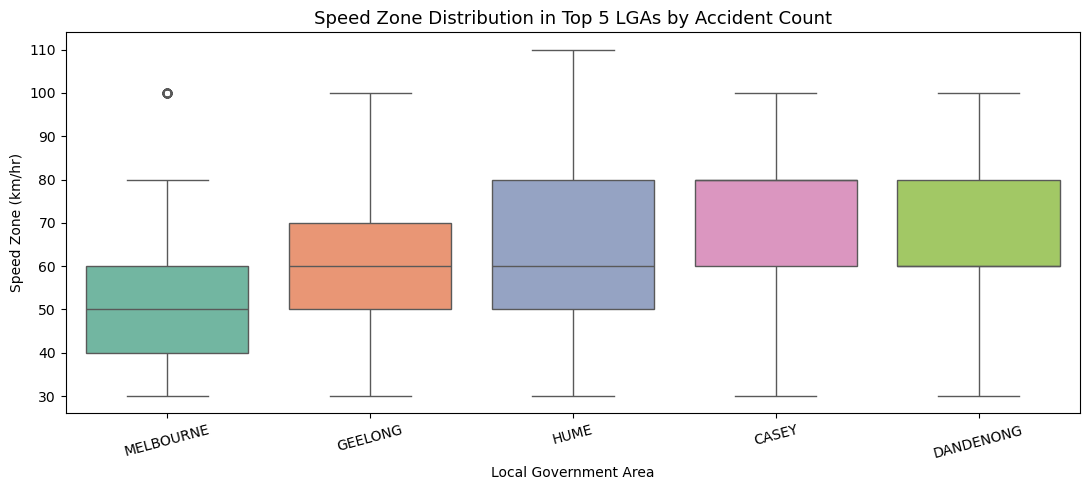

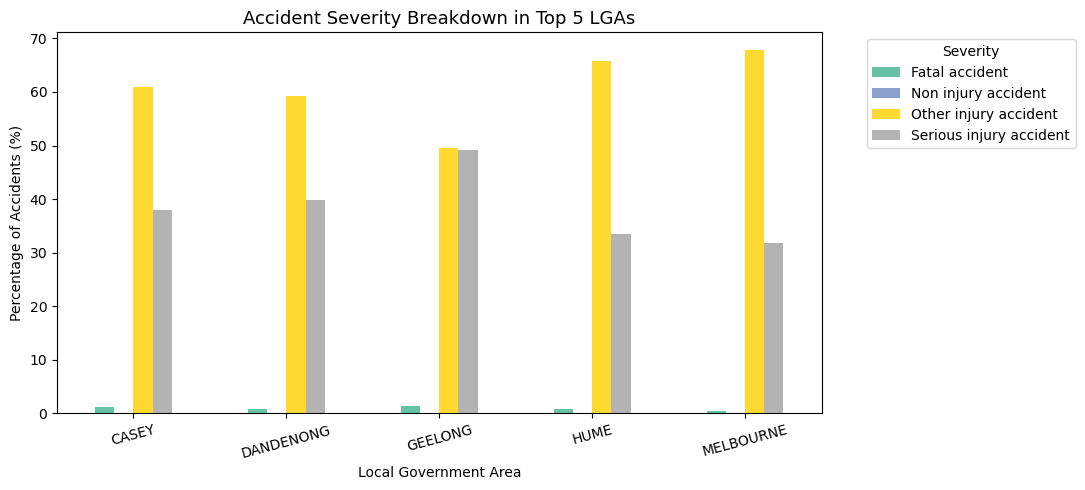

In [15]:
# Task 2.3: Crash Distribution by Geographic Area and Risk Factors

# 1. Identify the top 5 LGAs by total accident count
top_5_lgas = df['LGA_NAME'].value_counts().nlargest(5).index
df_top5 = df[df['LGA_NAME'].isin(top_5_lgas)].copy()

# --- Chart 1: Risk Factor 1 — Speed Zone Distribution ---
plt.figure(figsize=(11, 5))
sns.boxplot(data=df_top5, x='LGA_NAME', y='SPEED_ZONE_NUM', palette="Set2")
plt.title('Speed Zone Distribution in Top 5 LGAs by Accident Count', fontsize=13)
plt.xlabel('Local Government Area')
plt.ylabel('Speed Zone (km/hr)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# --- Chart 2: Risk Factor 2 — Accident Severity Breakdown ---
severity_counts = df_top5.groupby(['LGA_NAME', 'SEVERITY']).size().unstack(fill_value=0)
severity_pct = severity_counts.div(severity_counts.sum(axis=1), axis=0) * 100

severity_pct.plot(kind='bar', figsize=(11, 5), colormap='Set2')
plt.title('Accident Severity Breakdown in Top 5 LGAs', fontsize=13)
plt.xlabel('Local Government Area')
plt.ylabel('Percentage of Accidents (%)')
plt.xticks(rotation=15)
plt.legend(title='Severity', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Q3 Insights:** The top 5 LGAs by accident count reflect high-traffic urban areas. The speed zone boxplots reveal differences in road infrastructure — some LGAs have a wider spread of speed zones, indicating a mix of suburban and arterial roads, while others cluster around lower urban speed limits. The severity breakdown shows that despite having high accident volumes, some LGAs maintain a lower proportion of serious/fatal crashes, possibly due to lower speed environments and better road infrastructure. LGAs with more high-speed zone accidents tend to show higher serious injury rates, consistent with the known relationship between vehicle speed and crash severity.